# Datacube(NASA POWER Climate Data) to GeoCroissant Conversion Workflow, Metadata Generation

This notebook demonstrates the conversion of NASA POWER climate datacube (Xarray Dataset) to GeoCroissant metadata format for standardized data discovery and FAIR data principles.

<img src="../asset/GeoCroissant.jpg" alt="GeoCroissant" width="150" style="float: right; margin-left: 50px;">

## Overview
- **Data Source**: NASA POWER MERRA2 temporal dataset
- **Format**: Zarr datacube stored on AWS S3
- **Variables**: Temperature at 2 Meters (T2M) and other climate variables
- **Coverage**: Global, monthly temporal resolution
- **Output**: GeoCroissant JSON-LD metadata for data cataloging

## Loading NASA POWER Dataset with Xarray

This cell demonstrates how to load the NASA POWER Zarr dataset using Xarray.

In [1]:
import xarray as xr

store = "https://nasa-power.s3.us-west-2.amazonaws.com/merra2/temporal/power_merra2_monthly_temporal_utc.zarr/"
ds = xr.open_zarr(store)

ds

<xarray.Dataset> Size: 231GB
Dimensions:          (time: 588, lat: 361, lon: 576)
Coordinates:
  * lat              (lat) float64 3kB -90.0 -89.5 -89.0 ... 89.0 89.5 90.0
  * lon              (lon) float64 5kB -180.0 -179.4 -178.8 ... 178.8 179.4
  * time             (time) datetime64[ns] 5kB 1981-01-31 ... 2029-12-31
Data variables: (12/472)
    CDD0             (time, lat, lon) float32 489MB dask.array<chunksize=(588, 30, 30), meta=np.ndarray>
    CDD10            (time, lat, lon) float32 489MB dask.array<chunksize=(588, 30, 30), meta=np.ndarray>
    CDD18_3          (time, lat, lon) float32 489MB dask.array<chunksize=(588, 30, 30), meta=np.ndarray>
    DISPH            (time, lat, lon) float32 489MB dask.array<chunksize=(588, 30, 30), meta=np.ndarray>
    EVLAND           (time, lat, lon) float32 489MB dask.array<chunksize=(588, 30, 30), meta=np.ndarray>
    EVLAND_00        (time, lat, lon) float32 489MB dask.array<chunksize=(588, 30, 30), meta=np.ndarray>
    ...               ...
    WS50M_MAX        (time, lat, lon) float32 489MB dask.array<chunksize=(588, 30, 30), meta=np.ndarray>
    WS50M_MAX_AVG    (time, lat, lon) float32 489MB dask.array<chunksize=(588, 30, 30), meta=np.ndarray>
    WS50M_MIN        (time, lat, lon) float32 489MB dask.array<chunksize=(588, 30, 30), meta=np.ndarray>
    WS50M_MIN_AVG    (time, lat, lon) float32 489MB dask.array<chunksize=(588, 30, 30), meta=np.ndarray>
    WS50M_RANGE      (time, lat, lon) float32 489MB dask.array<chunksize=(588, 30, 30), meta=np.ndarray>
    Z0M              (time, lat, lon) float32 489MB dask.array<chunksize=(588, 30, 30), meta=np.ndarray>
Attributes: (12/37)
    acknowledgement:            The Prediction of Worldwide Energy Resources ...
    comment:                    POWER data version 10.0.0 uses the source dat...
    conventions:                CF-1.8, ACDD-1.3
    creator_email:              bradley.macpherson@nasa.gov
    creator_name:               Bradley Macpherson
    date_created:               2024-08-19T08:32:59Z
    ...                         ...
    time_coverage_end:          2029-12-31T00:00:00
    time_coverage_resolution:   P1ME
    time_coverage_start:        1981-01-01T00:00:00
    time_standard:              Universal Time Coordinated (UTC)
    title:                      POWER Universal Time Coordinated (UTC) Time S...
    version:                    POWER Version 10.0.0

## Visualizing Temperature Data

This cell creates a basic visualization of the Temperature at 2 Meters (T2M) variable for the first time step.

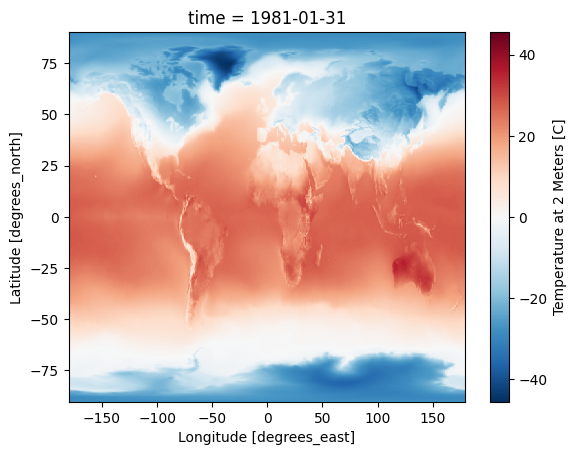

In [2]:
ds.T2M.isel(time=0).plot()

## GeoCroissant Converter

In [3]:
import json
from datetime import datetime
import xarray as xr
import hashlib
import pandas as pd


def create_nasa_t2m_croissant():
    """Create GeoCroissant metadata for NASA T2M following TTL specifications."""
    
    zarr_url = "https://nasa-power.s3.us-west-2.amazonaws.com/merra2/temporal/power_merra2_monthly_temporal_utc.zarr/"
    
    # Load dataset
    ds_full = xr.open_zarr(zarr_url)
    
    # Get time bounds to make it universal
    start_date = pd.to_datetime(ds_full.time.values[0]).strftime('%Y-%m-%d')
    end_date = pd.to_datetime(ds_full.time.values[-1]).strftime('%Y-%m-%d')
    
    # Generate checksum
    hash_input = f"{zarr_url}T2M".encode('utf-8')
    checksum = hashlib.sha256(hash_input).hexdigest()
    
    # TTL-compliant GeoCroissant metadata
    croissant = {
        "@context": {
            "@language": "en",
            "@vocab": "https://schema.org/",
            "citeAs": "cr:citeAs",
            "column": "cr:column",
            "conformsTo": "dct:conformsTo",
            "cr": "http://mlcommons.org/croissant/",
            "geocr": "http://mlcommons.org/croissant/geo/",
            "rai": "http://mlcommons.org/croissant/RAI/",
            "dct": "http://purl.org/dc/terms/",
            "sc": "https://schema.org/",
            "data": {
                "@id": "cr:data",
                "@type": "@json"
            },
            "examples": {
                "@id": "cr:examples",
                "@type": "@json"
            },
            "dataType": {
                "@id": "cr:dataType",
                "@type": "@vocab"
            },
            "equivalentProperty": "cr:equivalentProperty",
            "extract": "cr:extract",
            "field": "cr:field",
            "fileProperty": "cr:fileProperty",
            "fileObject": "cr:fileObject",
            "fileSet": "cr:fileSet",
            "format": "cr:format",
            "includes": "cr:includes",
            "isLiveDataset": "cr:isLiveDataset",
            "jsonPath": "cr:jsonPath",
            "key": "cr:key",
            "md5": "cr:md5",
            "parentField": "cr:parentField",
            "path": "cr:path",
            "recordSet": "cr:recordSet",
            "references": "cr:references",
            "regex": "cr:regex",
            "repeated": "cr:repeated",
            "replace": "cr:replace",
            "samplingRate": "cr:samplingRate",
            "separator": "cr:separator",
            "source": "cr:source",
            "subField": "cr:subField",
            "transform": "cr:transform"
        },
        "@type": "sc:Dataset",
        "name": "NASA POWER T2M",
        "description": "Temperature at 2 Meters monthly data",
        "version": "1.0.0",
        "license": "CC-BY-4.0",
        "conformsTo": [
            "http://mlcommons.org/croissant/1.1",
            "http://mlcommons.org/croissant/geo/1.0"
        ],
        "citeAs": "@dataset{nasa_power_t2m, title={NASA POWER T2M}, url={https://nasa-power.s3.us-west-2.amazonaws.com}}",
        "datePublished": start_date,
        
        # Standard spatial coverage using schema.org
        "spatialCoverage": {
            "@type": "Place",
            "geo": {
                "@type": "GeoShape",
                "box": "-90.0 -180.0 90.0 179.375"
            }
        },
        
        # GeoCroissant spatial properties
        "geocr:coordinateReferenceSystem": "EPSG:4326",
        "geocr:spatialResolution": {
            "@type": "QuantitativeValue",
            "value": 0.5,
            "unitText": "degrees"
        },
        "geocr:temporalResolution": {
            "@type": "QuantitativeValue", 
            "value": 1,
            "unitText": "month"
        },
        
        # Temporal coverage
        "temporalCoverage": f"{start_date}/{end_date}",
        
        "keywords": ["temperature", "climate", "nasa power", "t2m"],
        
        "distribution": [
            {
                "@type": "cr:FileObject",
                "@id": "zarr-data",
                "name": "zarr-data",
                "contentUrl": zarr_url,
                "encodingFormat": "application/zarr",
                "md5": checksum[:32]
            }
        ],
        
        "recordSet": [
            {
                "@type": "cr:RecordSet",
                "name": "t2m_data",
                "field": [
                    {
                        "@type": "cr:Field",
                        "name": "T2M",
                        "description": "Temperature at 2 Meters",
                        "dataType": "sc:Float",
                        "source": {
                            "fileObject": {
                                "@id": "zarr-data"
                            }
                        }
                    },
                    {
                        "@type": "cr:Field", 
                        "name": "latitude",
                        "description": "Latitude coordinate",
                        "dataType": "sc:Float",
                        "source": {
                            "fileObject": {
                                "@id": "zarr-data"
                            }
                        }
                    },
                    {
                        "@type": "cr:Field",
                        "name": "longitude",
                        "description": "Longitude coordinate", 
                        "dataType": "sc:Float",
                        "source": {
                            "fileObject": {
                                "@id": "zarr-data"
                            }
                        }
                    },
                    {
                        "@type": "cr:Field",
                        "name": "time",
                        "description": "Time coordinate",
                        "dataType": "sc:Text",
                        "source": {
                            "fileObject": {
                                "@id": "zarr-data"
                            }
                        }
                    }
                ]
            }
        ]
    }
    
    # Save metadata
    with open("nasa_t2m_croissant.json", "w") as f:
        json.dump(croissant, f, indent=2)
    
    return croissant


# Execute
croissant = create_nasa_t2m_croissant()

In [4]:
import json

# Read and print the metadata
with open('nasa_t2m_croissant.json', 'r') as f:
    metadata = json.load(f)

# Pretty print the metadata
print(json.dumps(metadata, indent=2))

{
  "@context": {
    "@language": "en",
    "@vocab": "https://schema.org/",
    "citeAs": "cr:citeAs",
    "column": "cr:column",
    "conformsTo": "dct:conformsTo",
    "cr": "http://mlcommons.org/croissant/",
    "geocr": "http://mlcommons.org/croissant/geo/",
    "rai": "http://mlcommons.org/croissant/RAI/",
    "dct": "http://purl.org/dc/terms/",
    "sc": "https://schema.org/",
    "data": {
      "@id": "cr:data",
      "@type": "@json"
    },
    "examples": {
      "@id": "cr:examples",
      "@type": "@json"
    },
    "dataType": {
      "@id": "cr:dataType",
      "@type": "@vocab"
    },
    "equivalentProperty": "cr:equivalentProperty",
    "extract": "cr:extract",
    "field": "cr:field",
    "fileProperty": "cr:fileProperty",
    "fileObject": "cr:fileObject",
    "fileSet": "cr:fileSet",
    "format": "cr:format",
    "includes": "cr:includes",
    "isLiveDataset": "cr:isLiveDataset",
    "jsonPath": "cr:jsonPath",
    "key": "cr:key",
    "md5": "cr:md5",
    "parent

## Validating GeoCroissant Metadata

In [5]:
!mlcroissant validate --jsonld=nasa_t2m_croissant.json

I0316 19:03:09.786525  4488 validate.py:53] Done.


## Temperature Data Visualization
 Single Month Temperature Plot


Loading data from: https://nasa-power.s3.us-west-2.amazonaws.com/merra2/temporal/power_merra2_monthly_temporal_utc.zarr/


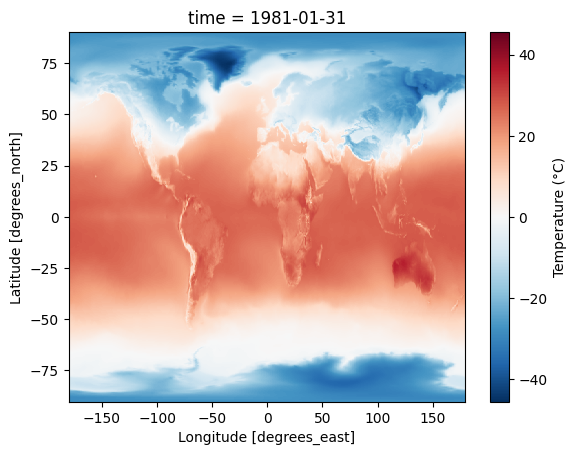

In [7]:
import json
import xarray as xr
import matplotlib.pyplot as plt

# 1. Load GeoCroissant metadata
with open('nasa_t2m_croissant.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)

# 2. Extract the Zarr datacube URL from the metadata
zarr_url = metadata['distribution'][0]['contentUrl']
print(f"Loading data from: {zarr_url}")

# 3. Load the dataset using Xarray
ds = xr.open_zarr(zarr_url)

# 4. Select the very first time slice of the T2M variable
first_month_data = ds['T2M'].isel(time=0)

# 5. Plot the simple visualization (using default standard size)
first_month_data.plot(cmap='RdBu_r', cbar_kwargs={'label': 'Temperature (°C)'})
plt.show()